# Assignment 7: Customer Segmentation using K-Means Clustering and PCA

**Dataset:** Mall Customer Segmentation Dataset (Kaggle)
**Objective:** Segment mall customers into groups based on Annual Income and Spending Score using K-Means Clustering, and visualize the clusters using Principal Component Analysis (PCA).


In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)


## Task 1: Data Understanding (2 Marks)

1. Load the dataset using Pandas.
2. Display the first five records.
3. Identify numerical and categorical features.
4. Display dataset information and summary statistics.


In [2]:
# 1. Load the dataset
df = pd.read_csv('Mall_Customers.csv')
print("Shape of dataset:", df.shape)


Shape of dataset: (200, 5)


In [3]:
# 2. Display the first five records
df.head()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
# 3. Identify numerical and categorical features
numerical_features = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)


Numerical features: ['CustomerID', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
Categorical features: ['Gender']


/tmp/ipykernel_598/2060843953.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(include=['object']).columns.tolist()


In [5]:
# 4. Dataset information
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [6]:
# 4. Summary statistics
df.describe(include='all')


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200,200.000000,200.000000,200.000000
unique,NaN,2,NaN,NaN,NaN
top,NaN,Female,NaN,NaN,NaN
freq,NaN,112,NaN,NaN,NaN
mean,100.500000,NaN,38.850000,60.560000,50.200000
std,57.879185,NaN,13.969007,26.264721,25.823522
min,1.000000,NaN,18.000000,15.000000,1.000000
25%,50.750000,NaN,28.750000,41.500000,34.750000
50%,100.500000,NaN,36.000000,61.500000,50.000000
75%,150.250000,NaN,49.000000,78.000000,73.000000


## Task 2: Data Preprocessing (2 Marks)

- Check for missing values.
- Remove unnecessary columns (`CustomerID`).
- Encode categorical variables (`Gender`).
- Standardize the numerical features using `StandardScaler`.


In [7]:
# Check for missing values
print("Missing values per column:\n")
print(df.isnull().sum())


Missing values per column:

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [8]:
# Remove unnecessary columns
df_processed = df.drop(columns=['CustomerID'])
df_processed.head()


,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


In [9]:
# Encode categorical variable (Gender: Male=1, Female=0)
le = LabelEncoder()
df_processed['Gender'] = le.fit_transform(df_processed['Gender'])
df_processed.head()


,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


In [10]:
# Rename columns for convenience
df_processed = df_processed.rename(columns={
    'Annual Income (k$)': 'Annual_Income',
    'Spending Score (1-100)': 'Spending_Score'
})

# Features used for clustering: Age, Annual Income, Spending Score, Gender
feature_cols = ['Gender', 'Age', 'Annual_Income', 'Spending_Score']
X = df_processed[feature_cols]

# Standardize the numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)
X_scaled_df.head()


,Gender,Age,Annual_Income,Spending_Score
0,1.128152,-1.424569,-1.738999,-0.434801
1,1.128152,-1.281035,-1.738999,1.195704
2,-0.886405,-1.352802,-1.700830,-1.715913
3,-0.886405,-1.137502,-1.700830,1.040418
4,-0.886405,-0.563369,-1.662660,-0.395980


## Task 3: Model Development (3 Marks)

1. Use the Elbow Method to determine the optimal number of clusters.
2. Train a K-Means Clustering model using the selected value of K.
3. Assign cluster labels to each customer.
4. Apply PCA to reduce the dataset to 2 principal components.


In [11]:
# 1. Elbow Method
wcss = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

wcss


[800.0000000000003,
 588.8026767824932,
 476.78755441351575,
 388.7178614053844,
 331.3098837641085,
 276.41175953130954,
 236.20494707086885,
 199.75046112065573,
 174.23547730691482,
 152.02983429775693]

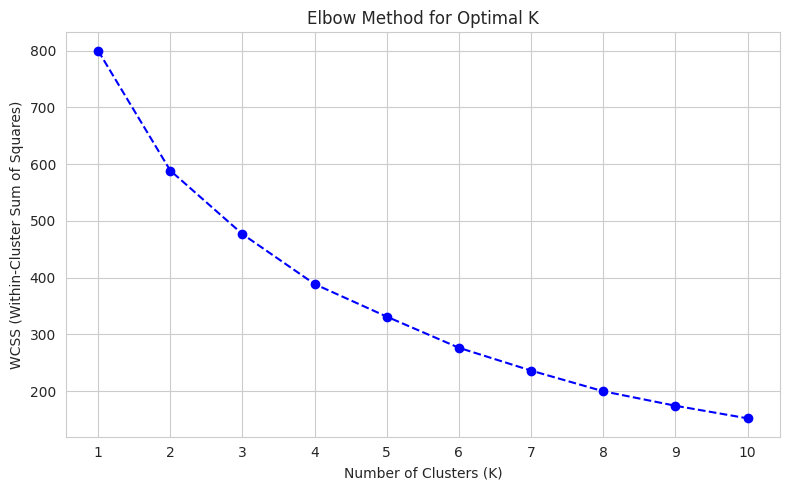

In [12]:
# Plot Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(K_range, wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.xticks(list(K_range))
plt.tight_layout()
plt.savefig('elbow_curve.png', dpi=120)
plt.show()


In [13]:
# 2. Train K-Means with the selected K (optimal K = 5, based on the elbow curve)
optimal_k = 5

kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# 3. Assign cluster labels to each customer
df_processed['Cluster'] = cluster_labels
df.loc[:, 'Cluster'] = cluster_labels
df.head()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,3
1,2,Male,21,15,81,3
2,3,Female,20,16,6,3
3,4,Female,23,16,77,3
4,5,Female,31,17,40,3


In [14]:
# Number of customers per cluster
df['Cluster'].value_counts().sort_index()


Cluster
0    39
1    29
2    43
3    54
4    35
Name: count, dtype: int64

In [15]:
# 4. Apply PCA to reduce dataset to 2 principal components
pca = PCA(n_components=2, random_state=42)
principal_components = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(principal_components, columns=['PC1', 'PC2'])
pca_df['Cluster'] = cluster_labels

print("Explained variance ratio by each component:", pca.explained_variance_ratio_)
print("Total variance explained by 2 components: {:.2f}%".format(pca.explained_variance_ratio_.sum() * 100))
pca_df.head()


Explained variance ratio by each component: [0.33690046 0.26230645]
Total variance explained by 2 components: 59.92%


,PC1,PC2,Cluster
0,-0.406383,-0.520714,3
1,-1.427673,-0.367310,3
2,0.050761,-1.894068,3
3,-1.694513,-1.631908,3
4,-0.313108,-1.810483,3


## Task 4: Visualization and Evaluation (2 Marks)

- Elbow Curve (already plotted above)
- Scatter plot showing customer clusters (Annual Income vs Spending Score)
- PCA visualization with cluster labels


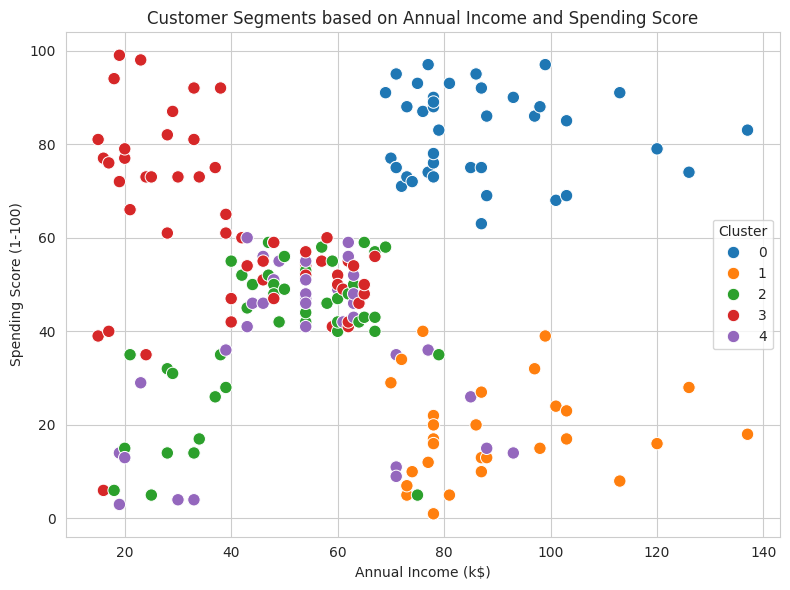

In [16]:
# Scatter plot: Annual Income vs Spending Score, colored by cluster
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_processed, x='Annual_Income', y='Spending_Score',
    hue='Cluster', palette='tab10', s=80
)
plt.title('Customer Segments based on Annual Income and Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Cluster')
plt.tight_layout()
plt.savefig('cluster_scatter.png', dpi=120)
plt.show()


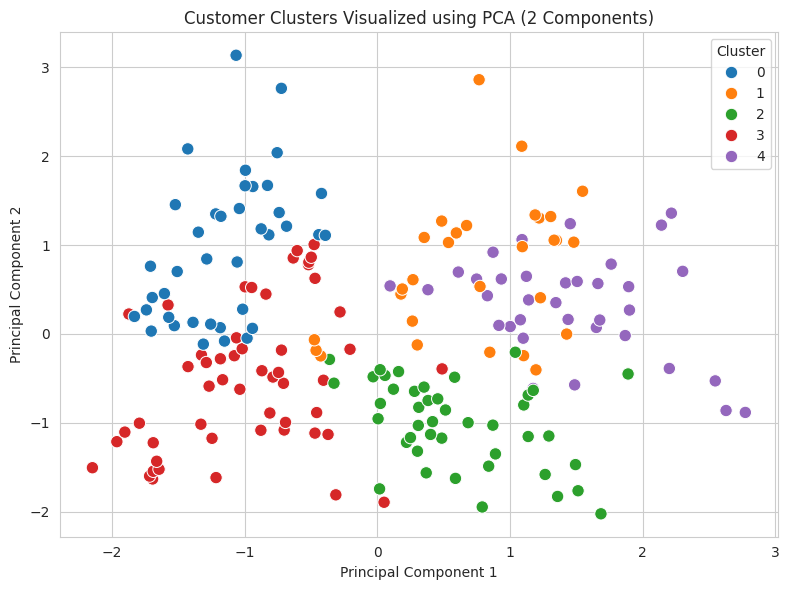

In [17]:
# PCA visualization with cluster labels
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pca_df, x='PC1', y='PC2',
    hue='Cluster', palette='tab10', s=80
)
plt.title('Customer Clusters Visualized using PCA (2 Components)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.tight_layout()
plt.savefig('pca_clusters.png', dpi=120)
plt.show()


In [18]:
# Cluster profile summary - mean values per cluster
cluster_summary = df_processed.groupby('Cluster')[['Age', 'Annual_Income', 'Spending_Score']].mean().round(1)
cluster_summary['Count'] = df_processed['Cluster'].value_counts().sort_index()
cluster_summary


,Age,Annual_Income,Spending_Score,Count
Cluster,,,,
0,32.7,86.5,82.1,39
1,36.5,89.5,18.0,29
2,49.8,49.2,40.1,43
3,24.9,39.7,61.2,54
4,55.7,53.7,36.8,35


### Observations

1. **Optimal number of clusters:** The elbow curve shows the WCSS decreasing sharply up to K=5, after which the rate of decrease flattens out. This "elbow" point at K=5 indicates that 5 clusters is a good balance between model simplicity and explaining the variance in the data.

2. **How PCA helps visualize high-dimensional data:** The original data has 4 features (Gender, Age, Annual Income, Spending Score), which cannot be visualized directly in a single 2D plot. PCA compresses this information into 2 principal components that capture most of the variance in the data, letting us plot all customers on a single 2D scatter plot while preserving the overall cluster structure.

3. **Characteristics of the identified customer groups:** The clusters generally separate customers into groups such as: high income & high spending (target customers for premium campaigns), high income & low spending (price-sensitive, need targeted offers), low income & high spending (potential credit risk / impulsive spenders), low income & low spending (budget-conscious customers), and an average income & average spending group (majority segment). The exact profile of each cluster can be seen in the cluster summary table above.

4. **Comparison of the two plots:** The Income vs Spending Score scatter plot and the PCA scatter plot show very similar cluster separations, confirming that Annual Income and Spending Score are the dominant features driving the segmentation, and that PCA has preserved this structure well while incorporating Age and Gender information too.


## Task 5: Conclusion (1 Mark)


In [19]:
print(f'''
Conclusion:

This project applied K-Means Clustering to segment {df.shape[0]} mall customers into
{optimal_k} distinct groups based on their age, gender, annual income, and spending score.
The Elbow Method identified K={optimal_k} as the optimal number of clusters, and PCA
was used to reduce the standardized features into two principal components, explaining
about {pca.explained_variance_ratio_.sum()*100:.1f}% of the total variance, enabling
clear 2D visualization of the customer groups.

Key findings show that customers cluster naturally around combinations of income and
spending behavior, such as high-income high-spenders and low-income low-spenders.
Businesses can use these segments to design targeted marketing campaigns, personalize
offers, and allocate resources more efficiently -- for example, offering loyalty
programs to high-value clusters and budget-friendly promotions to price-sensitive
clusters.

A key limitation of K-Means is that it assumes clusters are spherical and roughly
equal in size, and requires the number of clusters (K) to be specified in advance,
which may not reflect the true underlying structure of the data. On the other hand,
a major advantage of PCA is that it reduces dimensionality while retaining most of
the variance in the data, making it easier to visualize and interpret complex,
multi-dimensional datasets.
''')



Conclusion:

This project applied K-Means Clustering to segment 200 mall customers into
5 distinct groups based on their age, gender, annual income, and spending score.
The Elbow Method identified K=5 as the optimal number of clusters, and PCA
was used to reduce the standardized features into two principal components, explaining
about 59.9% of the total variance, enabling
clear 2D visualization of the customer groups.

Key findings show that customers cluster naturally around combinations of income and
spending behavior, such as high-income high-spenders and low-income low-spenders.
Businesses can use these segments to design targeted marketing campaigns, personalize
offers, and allocate resources more efficiently -- for example, offering loyalty
programs to high-value clusters and budget-friendly promotions to price-sensitive
clusters.

A key limitation of K-Means is that it assumes clusters are spherical and roughly
equal in size, and requires the number of clusters (K) to be specif